In [5]:
import tensorflow as tf
# from training_model import ctc_loss_lambda

In [8]:
def ctc_loss_lambda(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    return tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)

In [9]:
# بازخوانی مدل ذخیره‌شده
loaded_model = tf.keras.models.load_model(
    "best_crnn_model.keras",
    custom_objects={"ctc_loss_lambda": ctc_loss_lambda}
)

print("مدل با موفقیت لود شد و آماده تست است.")

مدل با موفقیت لود شد و آماده تست است.


In [17]:
import numpy as np
from PIL import Image

In [ ]:
t = Image.open("C:\\Users\\MEHDI\\Desktop\\Projects\\persian-letters-ocr\\data\\synthetic_plates_crnn\\images\\")

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\MEHDI\\Desktop\\Projects\\persian-letters-ocr\\data\\synthetic_plates_crnn\\images'

: 

In [33]:
t = np.array(t)

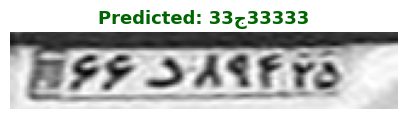

In [35]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# ۱. پیکربندی ابعاد مدل و لیست کاراکترها
# ---------------------------------------------------------
IMG_WIDTH = 160
IMG_HEIGHT = 32

VOCABULARY = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9",
              "الف", "ب", "پ", "ت", "ث", "ج", "چ", "ح", "خ", "د",
              "ذ", "ر", "ز", "ژ", "س", "ش", "ص", "ض", "ط", "ظ",
              "ع", "غ", "ف", "ق", "ک", "گ", "ل", "م", "ن", "و", "ه", "ی"]

# بارگذاری مدل بدون نیاز به تابع ctc_loss
model = tf.keras.models.load_model("best_crnn_model.keras", compile=False)

# ---------------------------------------------------------
# ۲. تابع تغییر سایز و پیش‌پردازش ورودی
# ---------------------------------------------------------
def prepare_image(image_input):
    """
    دریافت تصویر (مسیر یا آرایه OpenCV) و تغییر ابعاد آن به (32, 160, 1)
    """
    # ۱. اگر ورودی مسیر فایل بود، آن را می‌خواند
    if isinstance(image_input, str):
        img = cv2.imread(image_input)
        if img is None:
            raise FileNotFoundError(f"تصویر در مسیر {image_input} پیدا نشد.")
    else:
        img = image_input.copy()

    # ۲. تبدیل به Grayscale در صورت ۳ کاناله بودن
    if len(img.shape) == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ۳. تغییر سایز به ابعاد مورد نیاز مدل (32x160)
    resized_img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_CUBIC)

    # ۴. نرمال‌سازی پیکسل‌ها (بازه 0 تا 1)
    normalized_img = resized_img.astype(np.float32) / 255.0

    # ۵. افزودن ابعاد شبکه: (1, 32, 160, 1)
    tensor_img = np.expand_dims(normalized_img, axis=-1)
    tensor_img = np.expand_dims(tensor_img, axis=0)

    return tensor_img, resized_img

# ---------------------------------------------------------
# ۳. تابع دکود کردن خروجی CTC
# ---------------------------------------------------------
def decode_prediction(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    results = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0]
    results = results.numpy()[0]

    chars = []
    for c in results:
        if c > 0 and c <= len(VOCABULARY):
            chars.append(VOCABULARY[c - 1])

    return "".join(chars)

# ---------------------------------------------------------
# ۴. تابع اصلی پیش‌بینی
# ---------------------------------------------------------
def predict_plate(image_input, show_result=True):
    # آماده‌سازی تصویر
    input_tensor, processed_img = prepare_image(image_input)

    # اجرای اینفرنس/پیش‌بینی
    preds = model.predict(input_tensor, verbose=0)
    predicted_text = decode_prediction(preds)

    # نمایش تصویر ورودی تغییر سایز یافته و خروجی
    if show_result:
        plt.figure(figsize=(5, 1.8))
        plt.imshow(processed_img, cmap='gray')
        plt.title(f"Predicted: {predicted_text}", fontsize=13, color='darkgreen', fontweight='bold')
        plt.axis("off")
        plt.show()

    return predicted_text

# ---------------------------------------------------------
# ۵. نحوه استفاده (مثال)
# ---------------------------------------------------------
# روش اول: پاس دادن مسیر تصویر
plate_text = predict_plate(t)

# روش دوم: پاس دادن فریم/تصویر خوانی‌شده با OpenCV
# frame = cv2.imread("crop_plate.png")
# plate_text = predict_plate(frame)